# **Scikit-learn Documentation**

**https://scikit-learn.org/stable/index.html**

#**Python Packages**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

#**Machine Learning On Housing Price Prediction**

##Dataset with numerical target

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 1000

# Features for housing data
square_footage = np.random.randint(800, 4000, n_samples)  # in square feet
bedrooms = np.random.randint(1, 6, n_samples)  # 1 to 5 bedrooms
bathrooms = np.random.randint(1, 4, n_samples)  # 1 to 3 bathrooms
house_age = np.random.randint(1, 100, n_samples)  # Age of the house in years
floors = np.random.randint(1, 3, n_samples)  # 1 or 2 floors
has_garage = np.random.choice([0, 1], n_samples)  # 0 or 1 (no garage, has garage)
distance_to_city = np.random.uniform(1, 30, n_samples)  # Distance to city center in miles
neighborhood_quality = np.random.randint(1, 6, n_samples)  # 1 to 5 scale (low to high)
property_tax_rate = np.random.uniform(0.5, 2.5, n_samples)  # Property tax rate in percentage
has_garden = np.random.choice([0, 1], n_samples)  # 0 or 1 (no garden, has garden)

# Target variable (price) based on a combination of features
price = (square_footage * 100) + (bedrooms * 15000) + (bathrooms * 10000) + \
        (house_age * -200) + (floors * 20000) + (has_garage * 25000) + \
        (distance_to_city * -500) + (neighborhood_quality * 10000) + \
        (property_tax_rate * -3000) + (has_garden * 15000)

# Create DataFrame for features
df_features = pd.DataFrame({
    'Square_Footage': square_footage,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'House_Age': house_age,
    'Floors': floors,
    'Has_Garage': has_garage,
    'Distance_to_City': distance_to_city,
    'Neighborhood_Quality': neighborhood_quality,
    'Property_Tax_Rate': property_tax_rate,
    'Has_Garden': has_garden
})

# Create DataFrame for target variable
df_target = pd.DataFrame(price, columns=['Price'])

# Combine features and target into one dataset
df_housing = pd.concat([df_features, df_target], axis=1)

df_housing.head()


,Square_Footage,Bedrooms,Bathrooms,House_Age,Floors,Has_Garage,Distance_to_City,Neighborhood_Quality,Property_Tax_Rate,Has_Garden,Price
0,3974,1,2,12,1,1,12.669782,5,1.556379,0,513995.973670
1,1660,5,2,2,2,0,26.653020,2,1.434522,1,317969.924145
2,2094,4,1,7,2,1,26.971323,5,0.713424,0,377374.067787
3,1930,2,2,80,2,0,27.366083,1,1.799112,1,272919.622631
4,1895,1,1,3,1,1,10.102464,5,2.235999,1,312140.770339


##Creating Features and Target Variable data frames

In [3]:
X = df_housing.drop('Price', axis=1)
y = df_housing['Price']

##Feature Engineering (Scaling/Encoding)

1.   Min/Max or Standardize scaling for numerical features
2.   Encoding for categorical feature (In this case target variable)



In [4]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int32  
 1   Bedrooms              1000 non-null   int32  
 2   Bathrooms             1000 non-null   int32  
 3   House_Age             1000 non-null   int32  
 4   Floors                1000 non-null   int32  
 5   Has_Garage            1000 non-null   int64  
 6   Distance_to_City      1000 non-null   float64
 7   Neighborhood_Quality  1000 non-null   int32  
 8   Property_Tax_Rate     1000 non-null   float64
 9   Has_Garden            1000 non-null   int64  
dtypes: float64(2), int32(6), int64(2)
memory usage: 54.8 KB


In [5]:
y.info()

<class 'pandas.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
1000 non-null   float64
dtypes: float64(1)
memory usage: 7.9 KB


In [6]:
#scale numerical features
scaler_x = MinMaxScaler()
X_scaled = scaler_x.fit_transform(X)

In [7]:
#scale target variable
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

## Visulaize Correlation

<Axes: >

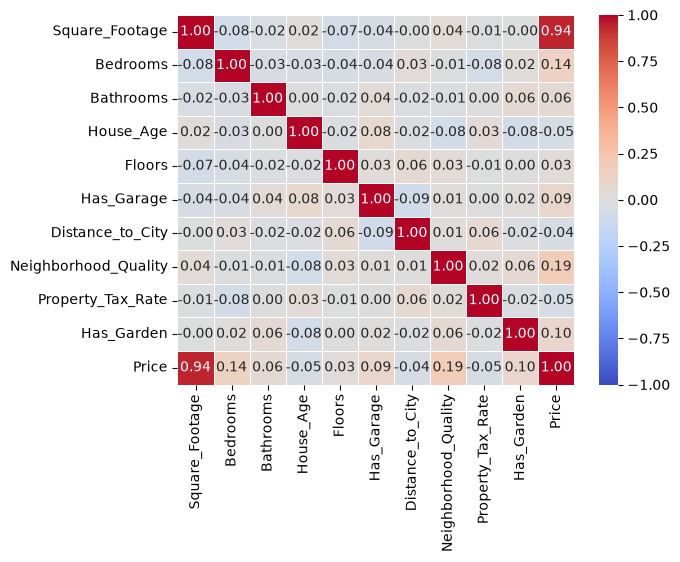

In [8]:
#plot correlation of features
sns.heatmap(df_housing.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)

##Spliting data into training and testing

In [9]:
#split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y_scaled, test_size=0.2, random_state=42)

## Apply Regression

### Linear Regression

In [10]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

In [11]:
# Extract coefficients and intercept
intercept = lin_reg.intercept_
coefficients = lin_reg.coef_

# Display the equation
equation = f"y = {intercept[0]:.2f}"
for i, coef in enumerate(coefficients[0]):
    equation += f" + ({coef:.2f}) * x{i+1}"

print("Linear Regression Equation:")
print(equation)

Linear Regression Equation:
y = -0.01 + (0.72) * x1 + (0.14) * x2 + (0.05) * x3 + (-0.04) * x4 + (0.05) * x5 + (0.06) * x6 + (-0.03) * x7 + (0.09) * x8 + (-0.01) * x9 + (0.03) * x10


In [12]:
#inverse predicted values
y_pred_lin_inv = scaler_y.inverse_transform(y_pred_lin)
y_test_inv = scaler_y.inverse_transform(y_test)

In [13]:
#evaluate the model
mse_lin = mean_squared_error(y_test_inv, y_pred_lin_inv)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test_inv, y_pred_lin_inv)

In [14]:
#generate report
print(f"Linear Regression - MSE: {mse_lin}, R^2 Score: {r2_lin}, RMSE: {rmse_lin}")

Linear Regression - MSE: 3.078964763269382e-20, R^2 Score: 1.0, RMSE: 1.754697912254238e-10


In [15]:
#create predicted vs actual price dataframe
df_pred_lin= pd.DataFrame({'Actual': y_test_inv.flatten(), 'Predicted_Linear': y_pred_lin_inv.flatten()})
df_pred_lin.head()

,Actual,Predicted_Linear
0,378671.043433,378671.043433
1,482020.696070,482020.696070
2,297024.833418,297024.833418
3,493703.141160,493703.141160
4,475344.058842,475344.058842


In [16]:
# Create the plot
fig = px.line(
    df_pred_lin,
    markers=True,
    title="Comparison of Actual and Predicted Price Using Linear regression",
)

# Show the plot
fig.show()

### Ridge Regression (L2)

In [17]:
# Perform Grid Search to tune alpha
param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, scoring="neg_mean_squared_error", cv=10)
grid_search.fit(X_train, y_train)
print("Best alpha:", grid_search.best_params_['alpha'])

Best alpha: 0.001


In [18]:
# Ridge Regression
ridge_reg = Ridge(alpha=0.001)
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_test)

In [19]:
# Extract coefficients and intercept
intercept = ridge_reg.intercept_
coefficients = ridge_reg.coef_

# Display the equation
equation = f"y = {np.ravel(intercept)[0]:.2f}"
for i, coef in enumerate(np.ravel(coefficients)):
    equation += f" + ({coef:.2f}) * x{i+1}"

print("Ridge Regression Equation:")
print(equation)

Ridge Regression Equation:
y = -0.01 + (0.72) * x1 + (0.14) * x2 + (0.05) * x3 + (-0.04) * x4 + (0.05) * x5 + (0.06) * x6 + (-0.03) * x7 + (0.09) * x8 + (-0.01) * x9 + (0.03) * x10


In [20]:
#inverse predicted values
y_pred_ridge_inv = scaler_y.inverse_transform(np.asarray(y_pred_ridge).reshape(-1, 1))
y_test_inv = scaler_y.inverse_transform(y_test)

In [21]:
#evaluate the model
mse_ridge = mean_squared_error(y_test_inv, y_pred_ridge_inv)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test_inv, y_pred_ridge_inv)

In [22]:
#generate report
print(f"Ridge Regression - MSE: {mse_ridge}, Ridge R^2 Score: {r2_ridge}, Ridge RMSE: {rmse_ridge}")

Ridge Regression - MSE: 1.5748045762681864, Ridge R^2 Score: 0.9999999997924716, Ridge RMSE: 1.2549121787074131


In [23]:
#create predicted vs actual price dataframe
df_pred_ridge= pd.DataFrame({'Actual': y_test_inv.flatten(), 'Predicted_Ridge': y_pred_ridge_inv.flatten()})
df_pred_ridge.head()

,Actual,Predicted_Ridge
0,378671.043433,378670.763313
1,482020.696070,482019.012959
2,297024.833418,297025.456821
3,493703.141160,493701.561312
4,475344.058842,475342.187714


In [24]:
# Create the plot
fig = px.line(
    df_pred_ridge,
    markers=True,
    title="Comparison of Actual and Predicted Price Using Ridge regression",
)

# Show the plot
fig.show()

### Lasso Regression (L1)

In [25]:
# Perform Grid Search to tune alpha
param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
ridge = Lasso()
grid_search = GridSearchCV(ridge, param_grid, scoring="neg_mean_squared_error", cv=10)
grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_['alpha'])

Best alpha: 0.001


In [26]:
# Lasso Regression
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)
y_pred_lasso = lasso_reg.predict(X_test)

In [27]:
# Extract coefficients and intercept
intercept = lasso_reg.intercept_
coefficients = lasso_reg.coef_

# Display the equation
equation = f"y = {intercept[0]:.2f}"
for i, coef in enumerate(coefficients):
    equation += f" + ({coef:.2f}) * x{i+1}"

print("Lasso Regression Equation:")
print(equation)

Lasso Regression Equation:
y = 0.00 + (0.71) * x1 + (0.13) * x2 + (0.04) * x3 + (-0.03) * x4 + (0.04) * x5 + (0.05) * x6 + (-0.02) * x7 + (0.08) * x8 + (-0.00) * x9 + (0.03) * x10


In [28]:
#inverse the values from scaller
y_pred_lasso_inv = scaler_y.inverse_transform(y_pred_lasso.reshape(-1,1))
y_test_inv = scaler_y.inverse_transform(y_test)

In [29]:
#evaluate the model
mse_lasso = mean_squared_error(y_test_inv, y_pred_lasso_inv)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test_inv, y_pred_lasso_inv)

In [30]:
#generate report
print(f"Lasso Regression - MSE: {mse_lasso}, Lasso R^2 Score: {r2_lasso}, Lasso RMSE: {rmse_lasso}")

Lasso Regression - MSE: 11936559.1097454, Lasso R^2 Score: 0.9984269945950288, Lasso RMSE: 3454.9325767293058


In [31]:
#create predicted vs actual price dataframe
df_pred_lasso= pd.DataFrame({'Actual': y_test_inv.flatten(),'Predicted_Lasso': y_pred_lasso_inv.flatten()})
df_pred_lasso.head()


,Actual,Predicted_Lasso
0,378671.043433,383837.886478
1,482020.696070,480859.577718
2,297024.833418,304513.867777
3,493703.141160,488246.777584
4,475344.058842,478266.728233


In [32]:
# Create the plot
fig = px.line(
    df_pred_lasso,
    markers=True,
    title="Comparison of Actual and Predicted Price Using Lasso regression",
)

# Show the plot
fig.show()

### Polynomial Regression

In [33]:
# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=True)  # Add interaction and square terms
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [34]:
# Train the model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Evaluate the model
y_pred = model.predict(X_test_poly)
print("MSE with Polynomial Features:", mean_squared_error(y_test, y_pred))

MSE with Polynomial Features: 2.530026760393458e-31


In [35]:
#inverse predicted values
y_pred_lin_inv = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

In [36]:
#evaluate the model
mse_lin = mean_squared_error(y_test_inv, y_pred_lin_inv)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test_inv, y_pred_lin_inv)

In [37]:
#generate report
print(f"Linear Regression - MSE: {mse_lin}, R^2 Score: {r2_lin}, RMSE: {rmse_lin}")

Linear Regression - MSE: 5.0101998830091864e-20, R^2 Score: 1.0, RMSE: 2.2383475786859345e-10


### Principle Component Analysis

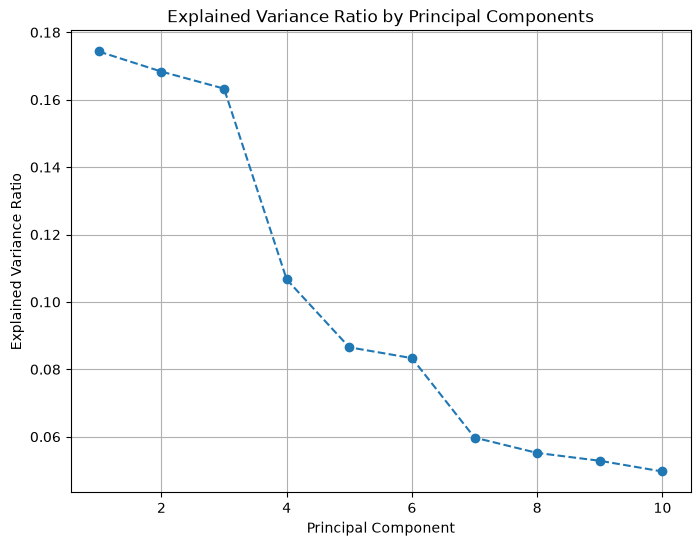

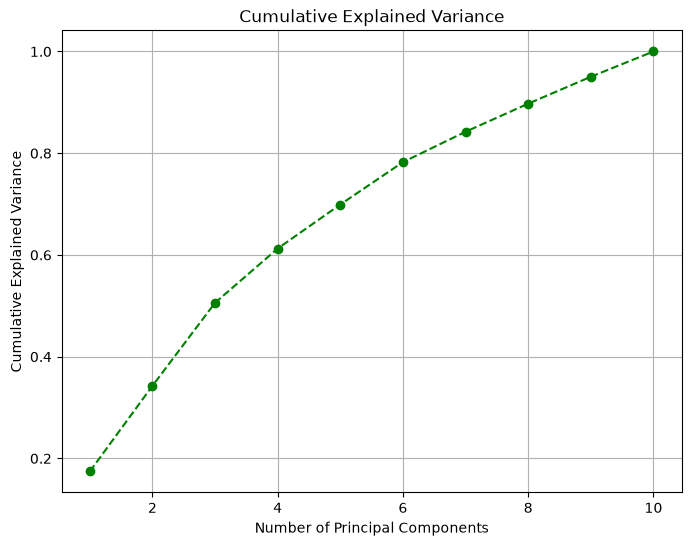

In [38]:
# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA-transformed features
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_columns)

# Visualize the explained variance ratio
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Explained Variance Ratio by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid()
plt.show()

# Cumulative explained variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--', color='green')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

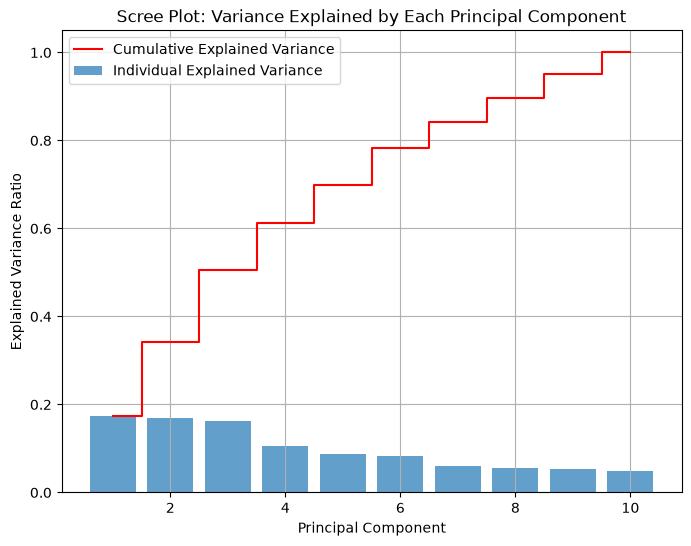

In [39]:
# Plot Scree Plot
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.7, label='Individual Explained Variance')
plt.step(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), where='mid', label='Cumulative Explained Variance', color='red')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot: Variance Explained by Each Principal Component')
plt.legend(loc='best')
plt.grid()
plt.show()

Since 10 Components Explains 90% Of Varaince

In [40]:
#data with 10 principle components
X_top_pca= X_pca[:,:10]

Get the factor laoding

In [41]:
# Get the loading matrix (coefficients of the components)
loadings = pca.components_

# Convert to DataFrame for better readability
loadings_df = pd.DataFrame(loadings.T, columns=[f"PC{i+1}" for i in range(10)], index=X.columns)

In [42]:
# Display the loadings
loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Square_Footage,-0.050917,0.035332,0.014302,-0.024888,-0.210319,-0.012684,-0.237480,0.818153,-0.333819,-0.337244
Bedrooms,-0.055017,0.057602,-0.017847,-0.132951,0.854653,0.416630,0.090602,0.203625,0.046241,-0.140848
Bathrooms,0.097228,0.116779,0.039576,0.975204,0.079654,0.125393,0.002398,0.042142,-0.020887,-0.005904
House_Age,0.004009,-0.048245,0.086628,0.019176,0.007456,-0.175481,0.094934,0.505116,0.675186,0.488779
Floors,0.487086,-0.636807,-0.586328,0.046592,0.056224,-0.016779,-0.029537,0.060387,0.018855,-0.054358
Has_Garage,0.699765,-0.107612,0.690398,-0.094088,0.040209,0.025367,0.024631,0.009387,-0.101444,-0.000890
Distance_to_City,-0.038301,-0.035673,-0.078206,-0.013201,0.017474,0.047348,0.488474,0.151758,-0.600255,0.605375
Neighborhood_Quality,0.066602,0.033256,-0.056621,-0.081880,-0.429356,0.873369,-0.013896,0.009987,0.159551,0.108068
Property_Tax_Rate,-0.005071,-0.012762,0.012525,0.016778,-0.171743,-0.040587,0.827888,0.065830,0.181466,-0.495547
Has_Garden,0.502055,0.748213,-0.400621,-0.110142,0.002807,-0.110248,0.026418,0.032342,0.027842,0.028422


Linear Regression After PCA

In [43]:
#split data into training and testing
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_top_pca,y_scaled, test_size=0.2, random_state=42)

In [44]:
# Linear Regression with PCA
lin_reg_pca = LinearRegression()
lin_reg_pca.fit(X_train_pca, y_train_pca)
y_pred_lin_pca = lin_reg_pca.predict(X_test_pca)

In [45]:
#inverse predicted values
y_pred_lin_pca_inv = scaler_y.inverse_transform(y_pred_lin_pca)
y_test_inv_pca = scaler_y.inverse_transform(y_test_pca)

In [46]:
#evaluate the model
mse_lin_pca = mean_squared_error(y_test_inv_pca, y_pred_lin_pca_inv)
rmse_lin_pca = np.sqrt(mse_lin_pca)
r2_lin_pca = r2_score(y_test_inv_pca, y_pred_lin_pca_inv)

In [47]:
#generate report
print(f"Linear Regression - MSE: {mse_lin_pca}, R^2 Score: {r2_lin_pca}, RMSE: {rmse_lin_pca}")

Linear Regression - MSE: 1.460708317540041e-20, R^2 Score: 1.0, RMSE: 1.2085976657018833e-10


#**Machine Learning On Real Housing Data**

##About this section

The section above used a **synthetic** dataset in which `Price` was built as an exact linear
combination of the features. That is why every model scored a perfect `R^2 = 1.0` with an MSE of
essentially zero, there was no noise left for the model to get wrong.

This section repeats the same workflow on a **real world** dataset, `housing_model/Housing.csv`,
which contains 545 actual house sales with 12 predictors and the sale `price` as the target. The
goal is to see how Linear, Ridge, Lasso and Polynomial regression behave once the relationship
between the features and the target is genuinely noisy.

In [48]:
#packages used by this section (imported separately so the section runs on its own)
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline

##Loading the real housing dataset

In [49]:
#load the real housing dataset
csv_path = "housing_model/Housing.csv"
if not os.path.exists(csv_path):
    csv_path = os.path.join("week 4", "housing_model", "Housing.csv")

df_house = pd.read_csv(csv_path)
df_house.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [50]:
#check the shape and the column data types
print(f"Rows: {df_house.shape[0]}, Columns: {df_house.shape[1]}")
df_house.info()

Rows: 545, Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [51]:
#check for missing values and duplicate rows
print(f"Missing values: {df_house.isnull().sum().sum()}, Duplicate rows: {df_house.duplicated().sum()}")

Missing values: 0, Duplicate rows: 0


In [52]:
#summary statistics of the numerical columns
df_house.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


##Feature Engineering (Scaling/Encoding)

1.   Binary encoding (yes/no to 1/0) for the six two level categorical features
2.   One hot encoding for `furnishingstatus`, which has three levels
3.   Min/Max scaling for the numerical features and for the target variable

In [53]:
#inspect the categorical columns before encoding
categorical_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
                    "airconditioning", "prefarea", "furnishingstatus"]

for col in categorical_cols:
    print(f"{col}: {df_house[col].unique().tolist()}")

mainroad: ['yes', 'no']
guestroom: ['no', 'yes']
basement: ['no', 'yes']
hotwaterheating: ['no', 'yes']
airconditioning: ['yes', 'no']
prefarea: ['yes', 'no']
furnishingstatus: ['furnished', 'semi-furnished', 'unfurnished']


In [54]:
#encode the binary yes/no columns as 1/0
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
               "airconditioning", "prefarea"]

df_house_encoded = df_house.copy()
for col in binary_cols:
    df_house_encoded[col] = df_house_encoded[col].map({"yes": 1, "no": 0})

In [55]:
#one hot encode furnishingstatus, dropping the first level to avoid the dummy variable trap
df_house_encoded = pd.get_dummies(df_house_encoded, columns=["furnishingstatus"],
                                  drop_first=True, dtype=int)
df_house_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [56]:
#confirm every column is numeric after encoding
print(f"Shape after encoding: {df_house_encoded.shape}")
df_house_encoded.dtypes

Shape after encoding: (545, 14)


price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object

##Creating Features and Target Variable data frames

In [57]:
X_house = df_house_encoded.drop("price", axis=1)
y_house = df_house_encoded["price"]

In [58]:
#list the final feature set and describe the target
print(f"Features ({X_house.shape[1]}): {list(X_house.columns)}")
print(f"Target 'price' -> mean: {y_house.mean():,.0f}, min: {y_house.min():,.0f}, max: {y_house.max():,.0f}")

Features (13): ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']
Target 'price' -> mean: 4,766,729, min: 1,750,000, max: 13,300,000


##Visualize Correlation

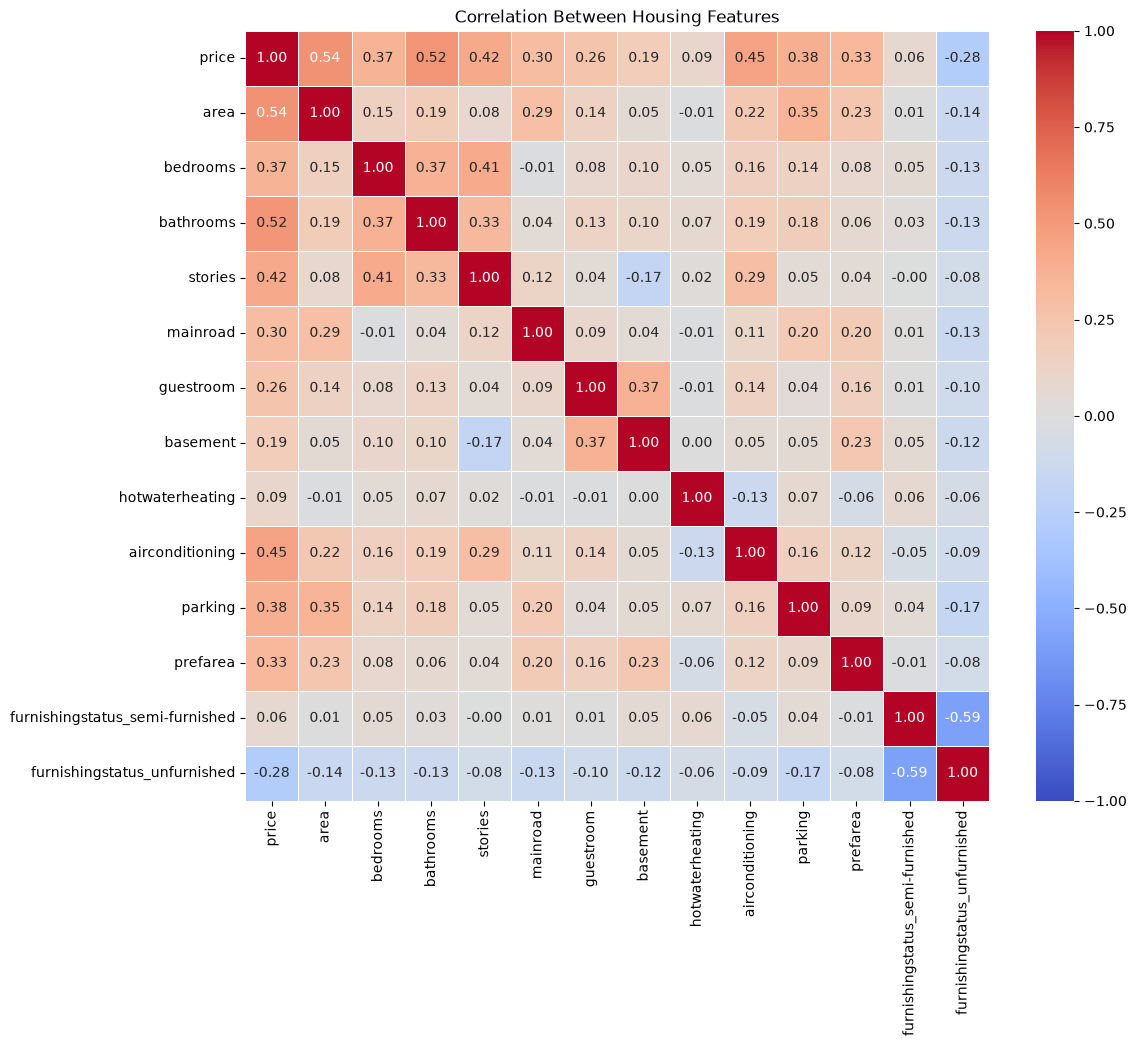

In [59]:
#plot correlation of features
plt.figure(figsize=(12, 10))
sns.heatmap(df_house_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Between Housing Features")
plt.show()

In [60]:
#rank the features by how strongly they correlate with price
df_house_encoded.corr()["price"].drop("price").sort_values(ascending=False)

area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

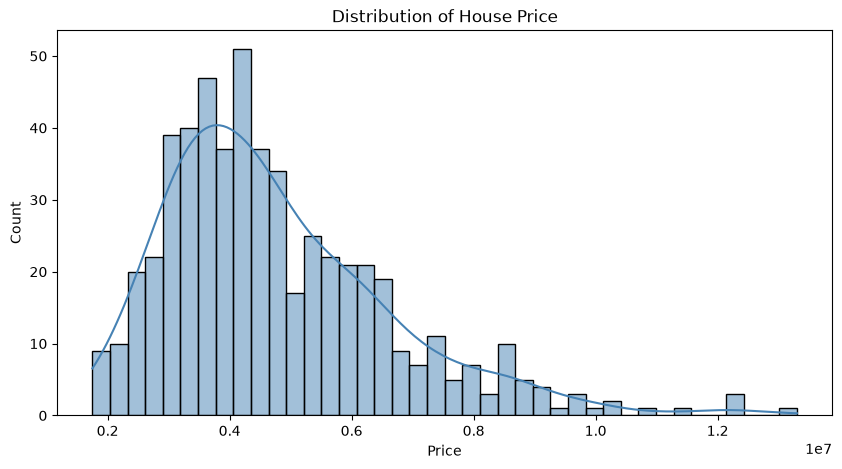

In [61]:
#distribution of the target variable
plt.figure(figsize=(10, 5))
sns.histplot(y_house, bins=40, kde=True, color="steelblue")
plt.title("Distribution of House Price")
plt.xlabel("Price")
plt.show()

##Scaling the features and the target

In [62]:
#scale numerical features
scaler_x_house = MinMaxScaler()
X_house_scaled = scaler_x_house.fit_transform(X_house)

In [63]:
#scale target variable
scaler_y_house = MinMaxScaler()
y_house_scaled = scaler_y_house.fit_transform(y_house.values.reshape(-1, 1))

##Spliting data into training and testing

In [64]:
#split data into training and testing
X_house_train, X_house_test, y_house_train, y_house_test = train_test_split(
    X_house_scaled, y_house_scaled, test_size=0.2, random_state=42)

print(f"Training set: {X_house_train.shape}, Testing set: {X_house_test.shape}")

Training set: (436, 13), Testing set: (109, 13)


###Helper functions

Three small helpers are defined once and reused by every model below, so the per model cells stay
focused on the algorithm itself.

Note on `inverse_price`: scikit-learn is not consistent about prediction shapes. With a 2D target
`LinearRegression` returns a column vector while `Ridge` and `Lasso` return a flat array, so the
predictions are reshaped before being scaled back to rupees.

In [65]:
#helper to convert scaled predictions of any shape back to actual prices
def inverse_price(scaled_values):
    return scaler_y_house.inverse_transform(np.asarray(scaled_values).reshape(-1, 1))

y_house_test_inv = inverse_price(y_house_test)

In [66]:
#helper to print a fitted linear model as a readable equation
def print_equation(model, feature_names, title):
    intercept = float(np.ravel(model.intercept_)[0])
    coefficients = np.ravel(model.coef_)

    equation = f"y = {intercept:.4f}"
    for name, coef in zip(feature_names, coefficients):
        equation += f" + ({coef:.4f} * {name})"

    print(title)
    print(equation)

In [67]:
#helper to plot actual against predicted prices for the first n test houses
def plot_actual_vs_predicted(actual, predicted, model_name, n=50):
    plt.figure(figsize=(12, 6))
    plt.plot(actual[:n], marker='o', linestyle='--', label='Actual')
    plt.plot(predicted[:n], marker='o', linestyle='--', label=f'Predicted ({model_name})')
    plt.title(f"Comparison of Actual and Predicted Price Using {model_name}")
    plt.xlabel("Test sample")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.show()

##Apply Regression

### Linear Regression

In [68]:
# Linear Regression
lin_reg_house = LinearRegression()
lin_reg_house.fit(X_house_train, y_house_train.ravel())
y_pred_lin_house = lin_reg_house.predict(X_house_test)

In [69]:
# Extract coefficients and intercept
print_equation(lin_reg_house, X_house.columns, "Linear Regression Equation:")

Linear Regression Equation:
y = 0.0414 + (0.2973 * area) + (0.0332 * bedrooms) + (0.2843 * bathrooms) + (0.1058 * stories) + (0.0319 * mainroad) + (0.0201 * guestroom) + (0.0338 * basement) + (0.0593 * hotwaterheating) + (0.0685 * airconditioning) + (0.0584 * parking) + (0.0545 * prefarea) + (-0.0110 * furnishingstatus_semi-furnished) + (-0.0358 * furnishingstatus_unfurnished)


In [70]:
#inverse predicted values
y_pred_lin_house_inv = inverse_price(y_pred_lin_house)

In [71]:
#evaluate the model
mse_lin_house = mean_squared_error(y_house_test_inv, y_pred_lin_house_inv)
rmse_lin_house = np.sqrt(mse_lin_house)
mae_lin_house = mean_absolute_error(y_house_test_inv, y_pred_lin_house_inv)
r2_lin_house = r2_score(y_house_test_inv, y_pred_lin_house_inv)

In [72]:
#generate report
print(f"Linear Regression - R^2 Score: {r2_lin_house:.4f}, RMSE: {rmse_lin_house:,.0f}, MAE: {mae_lin_house:,.0f}, MSE: {mse_lin_house:.4e}")

Linear Regression - R^2 Score: 0.6529, RMSE: 1,324,507, MAE: 970,043, MSE: 1.7543e+12


In [73]:
#create predicted vs actual price dataframe
df_pred_lin_house = pd.DataFrame({'Actual': y_house_test_inv.flatten(),
                                  'Predicted_Linear': y_pred_lin_house_inv.flatten()})
df_pred_lin_house.head()

,Actual,Predicted_Linear
0,4060000.0,5.164654e+06
1,6650000.0,7.224722e+06
2,3710000.0,3.109863e+06
3,6440000.0,4.612075e+06
4,2800000.0,3.294646e+06


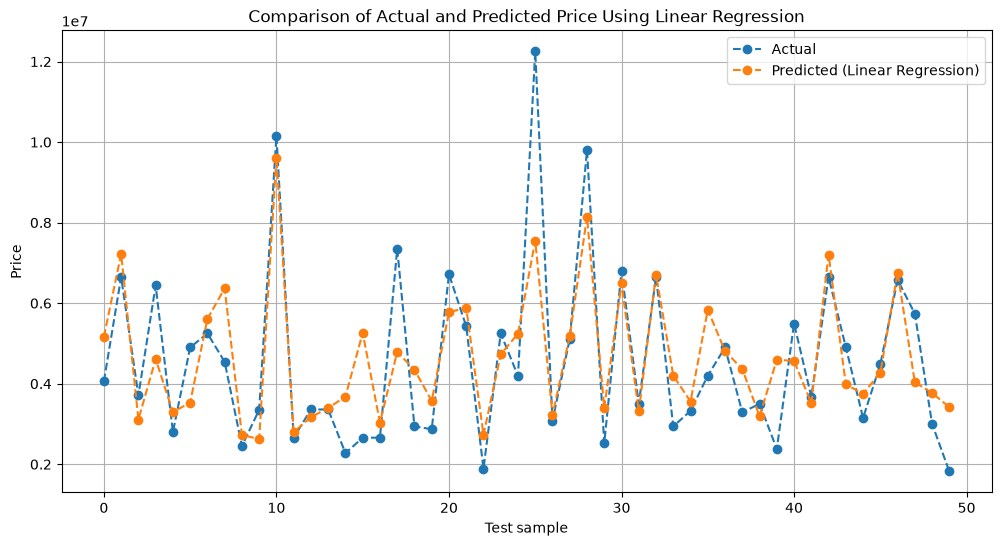

In [74]:
#plot actual against predicted price
plot_actual_vs_predicted(y_house_test_inv.flatten(), y_pred_lin_house_inv.flatten(), "Linear Regression")

### Ridge Regression (L2)

In [75]:
# Perform Grid Search to tune alpha
param_grid_house = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search_ridge_house = GridSearchCV(Ridge(), param_grid_house, scoring="neg_mean_squared_error", cv=10)
grid_search_ridge_house.fit(X_house_train, y_house_train.ravel())

best_alpha_ridge_house = grid_search_ridge_house.best_params_['alpha']
print("Best alpha:", best_alpha_ridge_house)

Best alpha: 0.1


In [76]:
# Ridge Regression
ridge_reg_house = Ridge(alpha=best_alpha_ridge_house)
ridge_reg_house.fit(X_house_train, y_house_train.ravel())
y_pred_ridge_house = ridge_reg_house.predict(X_house_test)

In [77]:
# Extract coefficients and intercept
print_equation(ridge_reg_house, X_house.columns, "Ridge Regression Equation:")

Ridge Regression Equation:
y = 0.0417 + (0.2940 * area) + (0.0343 * bedrooms) + (0.2817 * bathrooms) + (0.1057 * stories) + (0.0321 * mainroad) + (0.0203 * guestroom) + (0.0337 * basement) + (0.0591 * hotwaterheating) + (0.0687 * airconditioning) + (0.0589 * parking) + (0.0546 * prefarea) + (-0.0110 * furnishingstatus_semi-furnished) + (-0.0359 * furnishingstatus_unfurnished)


In [78]:
#inverse predicted values
y_pred_ridge_house_inv = inverse_price(y_pred_ridge_house)

In [79]:
#evaluate the model
mse_ridge_house = mean_squared_error(y_house_test_inv, y_pred_ridge_house_inv)
rmse_ridge_house = np.sqrt(mse_ridge_house)
mae_ridge_house = mean_absolute_error(y_house_test_inv, y_pred_ridge_house_inv)
r2_ridge_house = r2_score(y_house_test_inv, y_pred_ridge_house_inv)

In [80]:
#generate report
print(f"Ridge Regression - R^2 Score: {r2_ridge_house:.4f}, RMSE: {rmse_ridge_house:,.0f}, MAE: {mae_ridge_house:,.0f}, MSE: {mse_ridge_house:.4e}")

Ridge Regression - R^2 Score: 0.6530, RMSE: 1,324,394, MAE: 968,800, MSE: 1.7540e+12


In [81]:
#create predicted vs actual price dataframe
df_pred_ridge_house = pd.DataFrame({'Actual': y_house_test_inv.flatten(),
                                    'Predicted_Ridge': y_pred_ridge_house_inv.flatten()})
df_pred_ridge_house.head()

,Actual,Predicted_Ridge
0,4060000.0,5.153377e+06
1,6650000.0,7.214434e+06
2,3710000.0,3.112237e+06
3,6440000.0,4.615907e+06
4,2800000.0,3.299736e+06


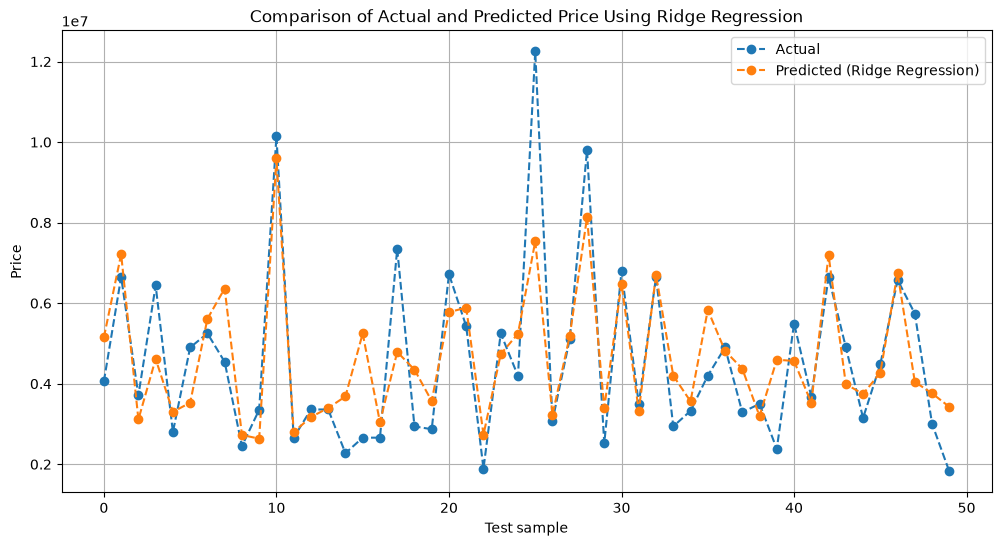

In [82]:
#plot actual against predicted price
plot_actual_vs_predicted(y_house_test_inv.flatten(), y_pred_ridge_house_inv.flatten(), "Ridge Regression")

### Lasso Regression (L1)

In [83]:
# Perform Grid Search to tune alpha
grid_search_lasso_house = GridSearchCV(Lasso(), param_grid_house, scoring="neg_mean_squared_error", cv=10)
grid_search_lasso_house.fit(X_house_train, y_house_train.ravel())

best_alpha_lasso_house = grid_search_lasso_house.best_params_['alpha']
print("Best alpha:", best_alpha_lasso_house)

Best alpha: 0.001


In [84]:
# Lasso Regression
lasso_reg_house = Lasso(alpha=best_alpha_lasso_house)
lasso_reg_house.fit(X_house_train, y_house_train.ravel())
y_pred_lasso_house = lasso_reg_house.predict(X_house_test)

In [85]:
# Extract coefficients and intercept
print_equation(lasso_reg_house, X_house.columns, "Lasso Regression Equation:")

Lasso Regression Equation:
y = 0.0606 + (0.2667 * area) + (0.0039 * bedrooms) + (0.2641 * bathrooms) + (0.1054 * stories) + (0.0293 * mainroad) + (0.0182 * guestroom) + (0.0324 * basement) + (0.0395 * hotwaterheating) + (0.0701 * airconditioning) + (0.0585 * parking) + (0.0529 * prefarea) + (-0.0026 * furnishingstatus_semi-furnished) + (-0.0299 * furnishingstatus_unfurnished)


In [86]:
#Lasso can shrink coefficients all the way to zero, so check how many features it actually kept
kept_features_house = int((lasso_reg_house.coef_ != 0).sum())
print(f"Lasso kept {kept_features_house} out of {len(lasso_reg_house.coef_)} features")

Lasso kept 13 out of 13 features


In [87]:
#inverse predicted values
y_pred_lasso_house_inv = inverse_price(y_pred_lasso_house)

In [88]:
#evaluate the model
mse_lasso_house = mean_squared_error(y_house_test_inv, y_pred_lasso_house_inv)
rmse_lasso_house = np.sqrt(mse_lasso_house)
mae_lasso_house = mean_absolute_error(y_house_test_inv, y_pred_lasso_house_inv)
r2_lasso_house = r2_score(y_house_test_inv, y_pred_lasso_house_inv)

In [89]:
#generate report
print(f"Lasso Regression - R^2 Score: {r2_lasso_house:.4f}, RMSE: {rmse_lasso_house:,.0f}, MAE: {mae_lasso_house:,.0f}, MSE: {mse_lasso_house:.4e}")

Lasso Regression - R^2 Score: 0.6383, RMSE: 1,352,211, MAE: 975,601, MSE: 1.8285e+12


In [90]:
#create predicted vs actual price dataframe
df_pred_lasso_house = pd.DataFrame({'Actual': y_house_test_inv.flatten(),
                                    'Predicted_Lasso': y_pred_lasso_house_inv.flatten()})
df_pred_lasso_house.head()

,Actual,Predicted_Lasso
0,4060000.0,5.052846e+06
1,6650000.0,7.081155e+06
2,3710000.0,3.273148e+06
3,6440000.0,4.700330e+06
4,2800000.0,3.294971e+06


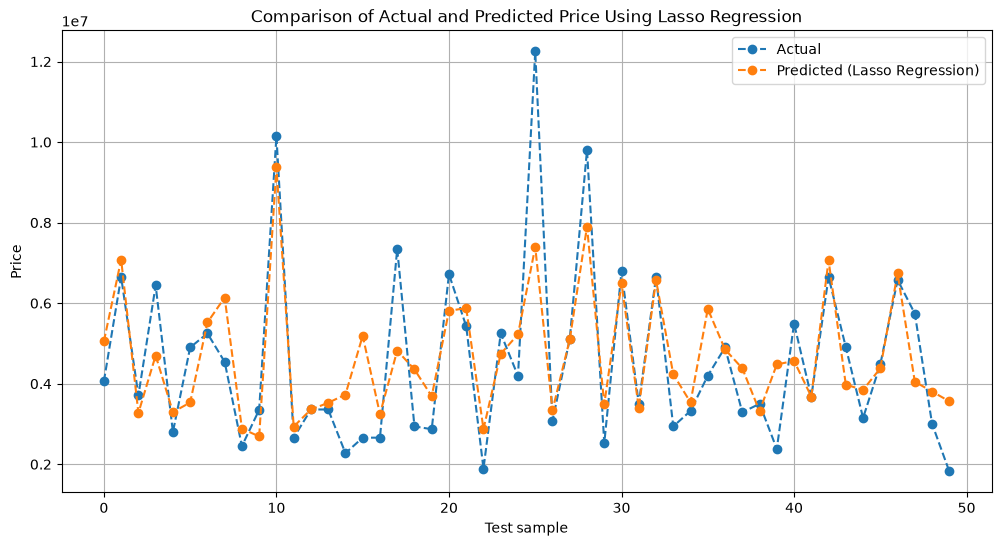

In [91]:
#plot actual against predicted price
plot_actual_vs_predicted(y_house_test_inv.flatten(), y_pred_lasso_house_inv.flatten(), "Lasso Regression")

### Polynomial Regression

In [92]:
# Create polynomial features
poly_house = PolynomialFeatures(degree=2, include_bias=True)  # Add interaction and square terms
X_house_train_poly = poly_house.fit_transform(X_house_train)
X_house_test_poly = poly_house.transform(X_house_test)

print(f"Features expanded from {X_house_train.shape[1]} to {X_house_train_poly.shape[1]}, on only {X_house_train.shape[0]} training rows")

Features expanded from 13 to 105, on only 436 training rows


In [93]:
# Train the model
poly_reg_house = LinearRegression()
poly_reg_house.fit(X_house_train_poly, y_house_train.ravel())
y_pred_poly_house = poly_reg_house.predict(X_house_test_poly)

In [94]:
#inverse predicted values
y_pred_poly_house_inv = inverse_price(y_pred_poly_house)

In [95]:
#evaluate the model
mse_poly_house = mean_squared_error(y_house_test_inv, y_pred_poly_house_inv)
rmse_poly_house = np.sqrt(mse_poly_house)
mae_poly_house = mean_absolute_error(y_house_test_inv, y_pred_poly_house_inv)
r2_poly_house = r2_score(y_house_test_inv, y_pred_poly_house_inv)

In [96]:
#generate report
print(f"Polynomial Regression - R^2 Score: {r2_poly_house:.4f}, RMSE: {rmse_poly_house:,.0f}, MAE: {mae_poly_house:,.0f}, MSE: {mse_poly_house:.4e}")

Polynomial Regression - R^2 Score: 0.6227, RMSE: 1,380,950, MAE: 1,038,189, MSE: 1.9070e+12


In [97]:
#compare the polynomial model against the plain linear model on the training set as well
print(f"Training R^2 - Linear: {lin_reg_house.score(X_house_train, y_house_train.ravel()):.4f}, Polynomial: {poly_reg_house.score(X_house_train_poly, y_house_train.ravel()):.4f}")
print(f"Testing  R^2 - Linear: {r2_lin_house:.4f}, Polynomial: {r2_poly_house:.4f}")

Training R^2 - Linear: 0.6859, Polynomial: 0.8014
Testing  R^2 - Linear: 0.6529, Polynomial: 0.6227


The polynomial model fits the **training** data noticeably better but scores **worse** on the
test data than plain linear regression. Expanding 13 features into 105 squared and interaction
terms while having only 436 training rows means the model starts describing the noise in the
training set rather than the underlying trend. This gap between training and testing performance
is the classic signature of **overfitting**, and it is the reason the simpler model is preferred
here.

###Note on Principal Component Analysis

PCA was applied to the synthetic dataset above to reduce 10 correlated features down to fewer
components. It is not repeated here because this dataset only has 13 features after encoding,
most of which are binary indicators. Compressing them into components would destroy the direct
interpretation of each coefficient (how much an extra bathroom or an air conditioner is worth)
which is the main practical value of a regression model on housing data.

##Model Comparison

In [98]:
#collect the results of every model into one table
df_results_house = pd.DataFrame({
    "Model": ["Linear Regression",
              "Ridge Regression (L2)",
              "Lasso Regression (L1)",
              "Polynomial Regression (degree 2)"],
    "R2 Score": [r2_lin_house, r2_ridge_house, r2_lasso_house, r2_poly_house],
    "RMSE": [rmse_lin_house, rmse_ridge_house, rmse_lasso_house, rmse_poly_house],
    "MAE": [mae_lin_house, mae_ridge_house, mae_lasso_house, mae_poly_house],
}).sort_values("R2 Score", ascending=False).reset_index(drop=True)

df_results_house

,Model,R2 Score,RMSE,MAE
0,Ridge Regression (L2),0.652984,1.324394e+06,9.688000e+05
1,Linear Regression,0.652924,1.324507e+06,9.700434e+05
2,Lasso Regression (L1),0.638253,1.352211e+06,9.756008e+05
3,Polynomial Regression (degree 2),0.622713,1.380950e+06,1.038189e+06


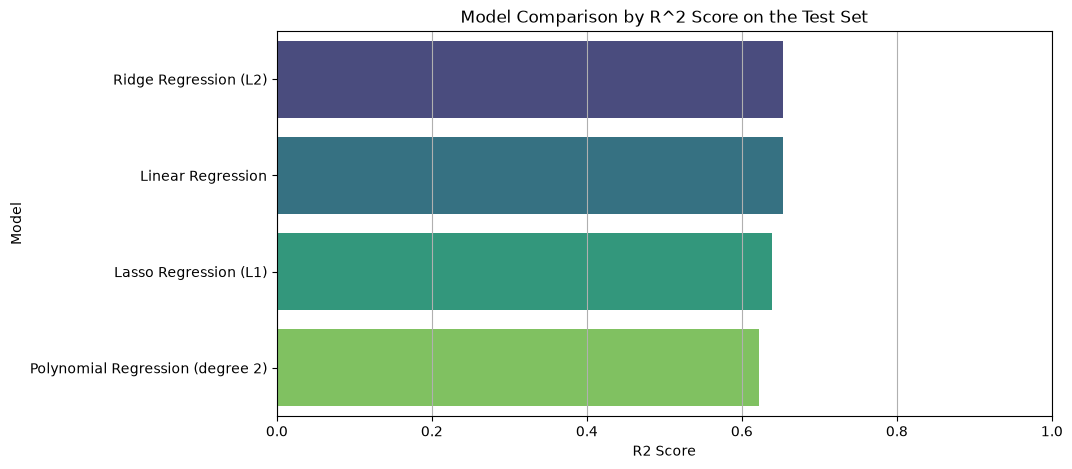

In [99]:
#compare the models visually
plt.figure(figsize=(10, 5))
sns.barplot(data=df_results_house, x="R2 Score", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Model Comparison by R^2 Score on the Test Set")
plt.xlim(0, 1)
plt.grid(axis='x')
plt.show()

In [100]:
#identify the best performing model
best_row_house = df_results_house.loc[0]
print(f"Best model: {best_row_house['Model']}")
print(f"R^2 Score: {best_row_house['R2 Score']:.4f}, RMSE: {best_row_house['RMSE']:,.0f}, MAE: {best_row_house['MAE']:,.0f}")
print(f"The RMSE is {best_row_house['RMSE'] / y_house.mean() * 100:.1f}% of the average house price of {y_house.mean():,.0f}")

Best model: Ridge Regression (L2)
R^2 Score: 0.6530, RMSE: 1,324,394, MAE: 968,800
The RMSE is 27.8% of the average house price of 4,766,729


##Saving the Best Model

The fitted model on its own is not enough to make predictions later, because any new house has to
be scaled with the **same** scaler that was fitted on the training data, the columns have to be in
the **same** order, and the output has to be scaled back into rupees. All of that is therefore
bundled into a single artifact and saved together.

In [101]:
#bundle the model with everything needed to reuse it later
housing_artifact = {
    "model": ridge_reg_house,
    "scaler_x": scaler_x_house,
    "scaler_y": scaler_y_house,
    "feature_names": list(X_house.columns),
    "best_alpha": best_alpha_ridge_house,
    "metrics": {"r2": r2_ridge_house, "rmse": rmse_ridge_house, "mae": mae_ridge_house},
}

In [102]:
#save the model to disk next to the dataset
model_path = os.path.join(os.path.dirname(csv_path), "housing_price_model.joblib")
joblib.dump(housing_artifact, model_path)

print(f"Saved model to {model_path} ({os.path.getsize(model_path):,} bytes)")

Saved model to housing_model\housing_price_model.joblib (2,780 bytes)


In [103]:
#load the saved model back and confirm it reproduces the same predictions
loaded_artifact = joblib.load(model_path)
reloaded_predictions = inverse_price(loaded_artifact["model"].predict(X_house_test))

print(f"Reloaded model: {type(loaded_artifact['model']).__name__}(alpha={loaded_artifact['best_alpha']})")
print(f"Matches the in memory model exactly: {np.allclose(reloaded_predictions, y_pred_ridge_house_inv)}")

Reloaded model: Ridge(alpha=0.1)
Matches the in memory model exactly: True


**Using the saved model on a brand new house**

In [104]:
#predict the price of a house the model has never seen, using only the saved artifact
new_house = pd.DataFrame([{
    "area": 7420, "bedrooms": 4, "bathrooms": 2, "stories": 3,
    "mainroad": 1, "guestroom": 0, "basement": 0, "hotwaterheating": 0,
    "airconditioning": 1, "parking": 2, "prefarea": 1,
    "furnishingstatus_semi-furnished": 0, "furnishingstatus_unfurnished": 0,
}])

new_house_scaled = loaded_artifact["scaler_x"].transform(new_house[loaded_artifact["feature_names"]])
new_house_price = inverse_price(loaded_artifact["model"].predict(new_house_scaled))

print(f"Predicted price for the new house: {new_house_price[0][0]:,.0f}")

Predicted price for the new house: 7,961,863


##Conclusion

1.   On real housing data the best model is **Ridge Regression** with `alpha = 0.1`, reaching an
     **R^2 of about 0.65** on the held out test set. In other words the 12 features explain
     roughly 65% of the variation in house prices, and the remaining 35% comes from factors that
     are simply not recorded in this dataset, such as the exact locality, the age of the property
     or the condition of the interior.
2.   Ridge and plain Linear Regression perform almost identically here. Regularisation has little
     to add because with 545 rows and only 13 features the model was never at serious risk of
     overfitting in the first place.
3.   **Lasso** scores slightly lower and, at the tuned `alpha`, keeps every feature rather than
     eliminating any, which indicates that none of the predictors is pure noise.
4.   **Polynomial Regression** performs the worst of the four despite being the most flexible,
     a clear demonstration that added model complexity hurts when the training set is small.
5.   The contrast with the synthetic dataset at the top of this notebook is the key takeaway. A
     perfect `R^2 = 1.0` was only achievable because the target was constructed from the features
     by formula. An `R^2` around 0.65 on genuine data is a realistic and honest result.